### 1. Import Library

In [ ]:
!pip install -q segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.5 MB/s eta 0:00:00


In [ ]:
import gdown
import zipfile
import os
import shutil
import random

### 2. Persiapan Dataset

Download dataset dari Google Drive

In [ ]:
file_id = '1o0b6Nqs89zYoyRcnih5oGS7sk0bIrImo'
url = f'https://drive.google.com/uc?id={file_id}'
output_zip = 'dataset.zip'

print("Mengunduh dataset dari Google Drive...")
gdown.download(url, output_zip, quiet=False)

Mengunduh dataset dari Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1o0b6Nqs89zYoyRcnih5oGS7sk0bIrImo
From (redirected): https://drive.google.com/uc?id=1o0b6Nqs89zYoyRcnih5oGS7sk0bIrImo&confirm=t&uuid=29a6405a-55e9-470b-9dbf-84be2ef27bd4
To: /content/dataset.zip
100%|██████████| 334M/334M [00:07<00:00, 47.3MB/s]


'dataset.zip'

Extract Dataset

In [ ]:
extract_dir = 'dataset'
print("\nMengekstrak dataset...")
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)


Mengekstrak dataset...


### 3. Membuat File `NCCTDataset`

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from PIL import Image
import random
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import segmentation_models_pytorch as smp

class NCCTDataset(Dataset):
    def __init__(self, split_dir, limit_size=None, transform=None):
        self.split_dir = split_dir
        self.transform = transform

        img_dir = os.path.join(split_dir, 'images')
        mask_dir = os.path.join(split_dir, 'masks')

        self.image_paths = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir)])
        self.mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)])

        if limit_size is not None:
            self.image_paths = self.image_paths[:limit_size]
            self.mask_paths = self.mask_paths[:limit_size]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_pil = Image.open(self.image_paths[idx]).convert("L")
        mask_pil = Image.open(self.mask_paths[idx]).convert("L")

        if self.transform:
            if hasattr(self.transform, 'processors') or 'Compose' in str(type(self.transform)):
                # Albumentations
                img_np = np.array(img_pil)
                mask_np = np.array(mask_pil)
                augmented = self.transform(image=img_np, mask=mask_np)
                img = augmented['image']
                mask = augmented['mask']
            else:
                # Torchvision fallback
                img = img_pil
                mask = mask_pil
                if self.split_dir.endswith('train'):
                    if random.random() > 0.5:
                        img = TF.hflip(img)
                        mask = TF.hflip(mask)
                    if random.random() > 0.5:
                        img = TF.vflip(img)
                        mask = TF.vflip(mask)
                    angle = random.uniform(-15, 15)
                    img = TF.rotate(img, angle)
                    mask = TF.rotate(mask, angle)
                img = self.transform(img)
                mask = self.transform(mask)
        else:
            img = TF.to_tensor(img_pil)
            mask = TF.to_tensor(mask_pil)

        # Binarize mask to 0.0 or 1.0 (Fixes bilinear interpolation bug)
        if isinstance(mask, torch.Tensor):
            mask = mask.float()
            if mask.max() > 1.0:
                mask = (mask > 127.0).float()
            else:
                mask = (mask > 0.5).float()
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
        else:
            mask_np = np.array(mask)
            if mask_np.max() > 1.0:
                mask = torch.tensor((mask_np > 127.0).astype(np.float32)).unsqueeze(0)
            else:
                mask = torch.tensor((mask_np > 0.5).astype(np.float32)).unsqueeze(0)

        label = 1.0 if torch.max(mask) > 0 else 0.0

        return img, mask, torch.tensor([label], dtype=torch.float32)

Cek Dataset

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Image shape: torch.Size([4, 1, 256, 256])
Mask shape: torch.Size([4, 1, 256, 256])
Max mask value: 1.00
Min mask value: 0.00


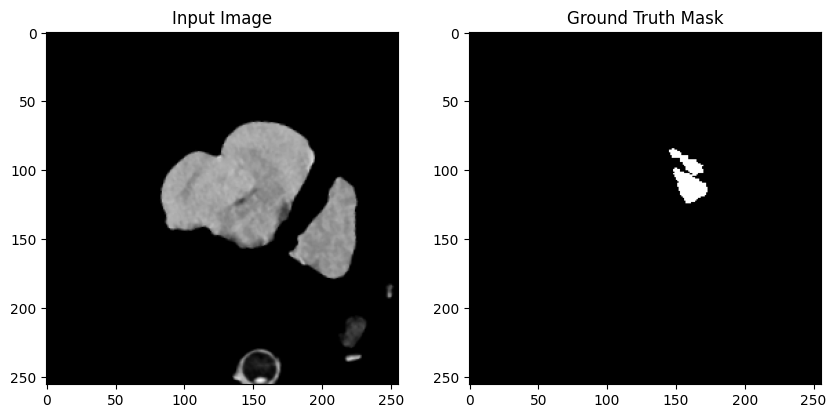

In [ ]:
import matplotlib.pyplot as plt

def get_dataloaders(base_dir, batch_size=4, limit_size=None):
    train_transform = A.Compose([
        A.Resize(256, 256),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
        A.Normalize(mean=(0.5,), std=(0.5,)),
        ToTensorV2(),
    ])

    val_transform = A.Compose([
        A.Resize(256, 256),
        A.Normalize(mean=(0.5,), std=(0.5,)),
        ToTensorV2(),
    ])

    train_dataset = NCCTDataset(os.path.join(base_dir, 'train'), limit_size=limit_size, transform=train_transform)
    val_dataset = NCCTDataset(os.path.join(base_dir, 'val'), limit_size=limit_size, transform=val_transform)
    test_dataset = NCCTDataset(os.path.join(base_dir, 'test'), limit_size=limit_size, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

# Ambil 1 batch data untuk verifikasi
train_loader, _, _ = get_dataloaders('dataset', batch_size=4)
images, masks, labels = next(iter(train_loader))

print(f"Image shape: {images.shape}")
print(f"Mask shape: {masks.shape}")
print(f"Max mask value: {masks.max():.2f}")
print(f"Min mask value: {masks.min():.2f}")

# Visualisasi sederhana
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(images[0][0].cpu().numpy(), cmap='gray'); plt.title("Input Image")
plt.subplot(1, 2, 2); plt.imshow(masks[0][0].cpu().numpy(), cmap='gray'); plt.title("Ground Truth Mask")
plt.show()

### 4. Membuat Model

#### 4.a. CSPNet

In [ ]:
class CSPBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        mid_channels = out_channels // 2

        self.main_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True)
        )

        self.skip_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True)
        )

        self.transition = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        main_out = self.main_conv(x)
        skip_out = self.skip_conv(x)
        merged = torch.cat([main_out, skip_out], dim=1)
        return self.transition(merged)

class NCCTSegmentationModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder (Backbone)
        self.initial_conv = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.layer1 = CSPBlock(32, 64)   # Output: 64 channels
        self.layer2 = CSPBlock(64, 128)  # Output: 128 channels
        self.layer3 = CSPBlock(128, 256) # Output: 256 channels

        self.pool = nn.MaxPool2d(2, 2)

        # Decoder with Skip Connections
        # features (256 channels) -> upconv1 (128 channels)
        self.upconv1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        # concat(up1:128, layer3:256) = 384
        self.decoder1 = CSPBlock(128 + 256, 128)

        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        # concat(up2:64, layer2:128) = 192
        self.decoder2 = CSPBlock(64 + 128, 64)

        self.upconv3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        # concat(up3:32, layer1:64) = 96
        self.decoder3 = CSPBlock(32 + 64, 32)

        self.seg_output = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        # Encoder
        x0 = F.relu(self.initial_conv(x))

        x1 = self.layer1(x0)
        p1 = self.pool(x1)

        x2 = self.layer2(p1)
        p2 = self.pool(x2)

        x3 = self.layer3(p2)
        features = self.pool(x3)

        # Decoder
        d1 = self.upconv1(features)
        d1 = torch.cat([d1, x3], dim=1)
        d1 = self.decoder1(d1)

        d2 = self.upconv2(d1)
        d2 = torch.cat([d2, x2], dim=1)
        d2 = self.decoder2(d2)

        d3 = self.upconv3(d2)
        d3 = torch.cat([d3, x1], dim=1)
        d3 = self.decoder3(d3)

        seg_out = self.seg_output(d3)
        return seg_out

#### 4.b. UNet

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.model = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=in_channels,
            classes=out_channels,
            activation=None
        )

    def forward(self, x):
        return self.model(x)


#### 4.c. Attention UNet

In [ ]:
class AttentionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.model = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=in_channels,
            classes=out_channels,
            attention_type="scse",
            activation=None
        )

    def forward(self, x):
        return self.model(x)


#### 4.d. ResUNet

In [ ]:
class ResUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.model = smp.Unet(
            encoder_name="resnet50",
            encoder_weights="imagenet",
            in_channels=in_channels,
            classes=out_channels,
            activation=None
        )

    def forward(self, x):
        return self.model(x)


### 5. Mendefinisikan Fungsi Loss

In [ ]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, gamma=2.0):
        super(BCEDiceLoss, self).__init__()
        self.bce_weight = bce_weight
        self.gamma = gamma

    def forward(self, inputs, targets):
        # Focal Loss (stabilized BCE for imbalanced data)
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        focal_loss = ((1 - pt) ** self.gamma * bce).mean()

        # Dice Loss
        inputs_sigmoid = torch.sigmoid(inputs)
        intersection = (inputs_sigmoid * targets).sum(dim=(2, 3))
        union = inputs_sigmoid.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice_score = (2. * intersection + 1e-6) / (union + 1e-6)
        dice_loss = 1.0 - dice_score.mean()

        return (self.bce_weight * focal_loss) + ((1 - self.bce_weight) * dice_loss)

def dice_coeff(pred, target, threshold=0.5, epsilon=1e-6):
    pred = (torch.sigmoid(pred) > threshold).float()
    target = (target > 0.5).float()
    inter = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    dice = (2. * inter + epsilon) / (union + epsilon)
    return dice.mean().item()

### 6. Fungsi `train_model` dan `eval_model`

Fungsi `train_model`

In [ ]:
import time

def train_model(model, train_loader, val_loader, epochs=40, model_name="Model", patience=10, min_delta=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    criterion = BCEDiceLoss(bce_weight=0.5).cuda()

    print(f"\nTraining {model_name}...")
    print(f"{'Epoch':<8} | {'T-Loss':<8} | {'V-Loss':<8} | {'V-Dice':<8} | {'LR':<10} | {'Time':<8}")
    print("-" * 70)

    best_dice = 0
    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_dice': []}

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss = 0
        for images, masks, _ in train_loader:
            images, masks = images.cuda(), masks.cuda()
            optimizer.zero_grad()
            seg_out = model(images)
            loss = criterion(seg_out, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss, val_dice = 0, 0
        with torch.no_grad():
            for images, masks, _ in val_loader:
                images, masks = images.cuda(), masks.cuda()
                seg_out = model(images)
                loss = criterion(seg_out, masks)
                val_loss += loss.item()
                val_dice += dice_coeff(seg_out, masks)

        end_time = time.time()
        duration = end_time - start_time

        avg_t_loss = train_loss / len(train_loader)
        avg_v_loss = val_loss / len(val_loader)
        avg_v_dice = val_dice / len(val_loader)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(avg_t_loss)
        history['val_loss'].append(avg_v_loss)
        history['val_dice'].append(avg_v_dice)

        scheduler.step(avg_v_loss)

        print(f"{epoch+1:<8} | {avg_t_loss:<8.4f} | {avg_v_loss:<8.4f} | {avg_v_dice:<8.4f} | {current_lr:<10.6f} | {duration:<8.2f}s")

        if avg_v_dice > best_dice:
            best_dice = avg_v_dice
            torch.save(model.state_dict(), f"{model_name.lower().replace(' ', '_')}_best.pth")

        if avg_v_loss < best_val_loss - min_delta:
            best_val_loss = avg_v_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break

    return model, history

Fungsi `eval_model`

In [ ]:
def eval_model(models_dict, test_loader):
    results = {}
    print(f"\n{'Model':<15} | {'Test Dice Score':<15}")
    print("-" * 35)

    for name, model in models_dict.items():
        model.eval()
        test_dice = 0
        with torch.no_grad():
            for images, masks, _ in test_loader:
                images, masks = images.cuda(), masks.cuda()
                seg_out = model(images)
                test_dice += dice_coeff(seg_out, masks)

        final_dice = test_dice / len(test_loader)
        results[name] = final_dice
        print(f"{name:<15} | {final_dice:<15.4f}")

    return results

### 7. Model Tambahan

#### a. UNet (EfficientNet-b3)
EfficientNet dikenal memiliki fitur ekstraksi yang sangat kuat dengan jumlah parameter yang relatif lebih sedikit, sehingga dapat menghasilkan akurasi yang lebih baik.

In [ ]:
class UNet_EffNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.model = smp.Unet(
            encoder_name="efficientnet-b3",
            encoder_weights="imagenet",
            in_channels=in_channels,
            classes=out_channels,
            activation=None
        )
    def forward(self, x):
        return self.model(x)


#### b. Linknet (ResNet34)
Linknet menggunakan koneksi antar blok encoder dan decoder untuk memulihkan resolusi spasial tanpa beban komputasi yang berat (mirip UNet tapi operasi penjumlahan, bukan konkatenasi).

In [ ]:
class Linknet_ResNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.model = smp.Linknet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=in_channels,
            classes=out_channels,
            activation=None
        )
    def forward(self, x):
        return self.model(x)


#### c. FPN (ResNeXt50)
Feature Pyramid Network (FPN) memiliki pendekatan peramida fitur untuk mengenali objek dalam berbagai skala, dipadukan dengan ResNeXt yang kuat.

In [ ]:
class FPN_ResNext(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.model = smp.FPN(
            encoder_name="resnext50_32x4d",
            encoder_weights="imagenet",
            in_channels=in_channels,
            classes=out_channels,
            activation=None
        )
    def forward(self, x):
        return self.model(x)


#### d. PSPNet (ResNet50)
Pyramid Scene Parsing Network (PSPNet) memanfaatkan modul global context untuk mengumpulkan informasi di berbagai sub-region.

In [ ]:
class PSPNet_ResNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.model = smp.PSPNet(
            encoder_name="resnet50",
            encoder_weights="imagenet",
            in_channels=in_channels,
            classes=out_channels,
            activation=None
        )
    def forward(self, x):
        return self.model(x)


#### e. PAN (MobileNetV2)
Pyramid Attention Network (PAN) menggabungkan attention feature untuk memusatkan segmentasi secara lebih presisi dengan backbone ringan MobileNetV2.

In [ ]:
class PAN_MobileNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.model = smp.PAN(
            encoder_name="mobilenet_v2",
            encoder_weights="imagenet",
            in_channels=in_channels,
            classes=out_channels,
            activation=None
        )
    def forward(self, x):
        return self.model(x)


### 8. Train dan Evaluasi Model Tambahan


Inisialisasi train dan val loader

In [ ]:
train_loader, val_loader, test_loader = get_dataloaders('dataset')
trained_models = {}
model_histories = {}

#### a. UNet (EfficientNet-b3) Training & Evaluation

In [ ]:
name = "UNet_EffNet"
model = UNet_EffNet().cuda()
m, h = train_model(model, train_loader, val_loader, epochs=5, model_name=name)
trained_models[name] = m
model_histories[name] = h

print(f"\nEvaluasi {name}:")
eval_model({name: m}, test_loader)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]


Training UNet_EffNet...
Epoch    | T-Loss   | V-Loss   | V-Dice   | LR         | Time    
----------------------------------------------------------------------
1        | 0.4294   | 0.3672   | 0.3519   | 0.000100   | 122.81  s
2        | 0.3487   | 0.3339   | 0.3964   | 0.000100   | 123.41  s
3        | 0.3276   | 0.3159   | 0.4255   | 0.000100   | 123.25  s
4        | 0.3174   | 0.3114   | 0.4335   | 0.000100   | 123.10  s
5        | 0.3089   | 0.3040   | 0.4463   | 0.000100   | 126.19  s

Evaluasi UNet_EffNet:

Model           | Test Dice Score
-----------------------------------
UNet_EffNet     | 0.4000         


{'UNet_EffNet': 0.3999880555359268}

#### b. Linknet (ResNet34) Training & Evaluation

In [ ]:
name = "Linknet_ResNet"
model = Linknet_ResNet().cuda()
m, h = train_model(model, train_loader, val_loader, epochs=5, model_name=name)
trained_models[name] = m
model_histories[name] = h

print(f"\nEvaluasi {name}:")
eval_model({name: m}, test_loader)


#### c. FPN (ResNeXt50) Training & Evaluation

In [ ]:
name = "FPN_ResNext"
model = FPN_ResNext().cuda()
m, h = train_model(model, train_loader, val_loader, epochs=5, model_name=name)
trained_models[name] = m
model_histories[name] = h

print(f"\nEvaluasi {name}:")
eval_model({name: m}, test_loader)


#### d. PSPNet (ResNet50) Training & Evaluation

In [ ]:
name = "PSPNet_ResNet"
model = PSPNet_ResNet().cuda()
m, h = train_model(model, train_loader, val_loader, epochs=5, model_name=name)
trained_models[name] = m
model_histories[name] = h

print(f"\nEvaluasi {name}:")
eval_model({name: m}, test_loader)


#### e. PAN (MobileNetV2) Training & Evaluation

In [ ]:
name = "PAN_MobileNet"
model = PAN_MobileNet().cuda()
m, h = train_model(model, train_loader, val_loader, epochs=5, model_name=name)
trained_models[name] = m
model_histories[name] = h

print(f"\nEvaluasi {name}:")
eval_model({name: m}, test_loader)


### 9. Visualisasi Prediksi vs Ground Truth
Bagian ini membantu untuk melihat secara visual performa model pada data testing.

In [ ]:
def visualize_all_models(models_dict, test_loader, num_samples=3):
    model_names = list(models_dict.keys())
    num_models = len(model_names)

    plt.figure(figsize=(20, num_samples * 4))

    with torch.no_grad():
        for i in range(num_samples):
            images, masks, _ = next(iter(test_loader))
            images_gpu = images.cuda()

            # Plot Input
            plt.subplot(num_samples, num_models + 2, i * (num_models + 2) + 1)
            plt.imshow(images[0][0].cpu().numpy(), cmap='gray')
            plt.title("Input")
            plt.axis('off')

            # Plot Ground Truth
            plt.subplot(num_samples, num_models + 2, i * (num_models + 2) + 2)
            plt.imshow(masks[0][0].cpu().numpy(), cmap='gray')
            plt.title("GT")
            plt.axis('off')

            # Plot each model's prediction
            for j, name in enumerate(model_names):
                model = models_dict[name]
                model.eval()
                out = model(images_gpu)
                pred = (torch.sigmoid(out) > 0.5).cpu().numpy()[0][0]

                plt.subplot(num_samples, num_models + 2, i * (num_models + 2) + 3 + j)
                plt.imshow(pred, cmap='gray')
                plt.title(name)
                plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Menampilkan semua hasil
visualize_all_models(trained_models, test_loader)